# Sprint 1 — Exploratory Data Analysis

UCI Chronic Kidney Disease dataset — 400 patient records, 24 clinical/lab features.

Goal: understand missingness, class balance, and feature distributions **before** committing to a cleaning strategy, so decisions in `src/data/preprocess.py` are based on what the data actually looks like, not assumptions.

In [ ]:
import sys
from pathlib import Path
sys.path.append(str(Path.cwd().parent))

import pandas as pd
import matplotlib.pyplot as plt
import config
from src.data.load_tabular import fetch_uci_ckd

df = fetch_uci_ckd()
print(f"Shape: {df.shape}")
df.head()

Shape: (400, 25)


,age,bp,sg,al,su,rbc,pc,pcc,ba,bgr,...,pcv,wc,rc,htn,dm,cad,appet,pe,ane,class
0,48.0,80.0,1.020,1.0,0.0,NaN,normal,notpresent,notpresent,121.0,...,44.0,7800.0,5.2,yes,yes,no,good,no,no,ckd
1,7.0,50.0,1.020,4.0,0.0,NaN,normal,notpresent,notpresent,NaN,...,38.0,6000.0,NaN,no,no,no,good,no,no,ckd
2,62.0,80.0,1.010,2.0,3.0,normal,normal,notpresent,notpresent,423.0,...,31.0,7500.0,NaN,no,yes,no,poor,no,yes,ckd
3,48.0,70.0,1.005,4.0,0.0,normal,abnormal,present,notpresent,117.0,...,32.0,6700.0,3.9,yes,no,no,poor,yes,yes,ckd
4,51.0,80.0,1.010,2.0,0.0,normal,normal,notpresent,notpresent,106.0,...,35.0,7300.0,4.6,no,no,no,good,no,no,ckd


## Missing values

Checked per column, both as counts and as a percentage of the 400 rows — some columns turn out to be missing far more often than others, which matters for whether imputation is reasonable or a column should be treated more carefully.

In [ ]:
missing = df.isna().sum().sort_values(ascending=False)
missing_pct = (missing / len(df) * 100).round(1)
pd.DataFrame({"missing_count": missing, "missing_pct": missing_pct})[missing > 0]

,missing_count,missing_pct
rbc,152,38.0
rc,131,32.8
wc,106,26.5
pot,88,22.0
sod,87,21.8
pcv,71,17.8
pc,65,16.2
hemo,52,13.0
su,49,12.2
sg,47,11.8


**Finding:** `rbc` (red blood cells) is missing in well over a third of rows, and `rc`/`wc` (red/white blood cell counts) are each missing in roughly a quarter to a third of rows. That's high enough that median/most-frequent imputation is a real modeling assumption, not a formality — worth stating plainly in the final report rather than glossing over.

## Class balance

class
ckd       250
notckd    150
Name: count, dtype: int64


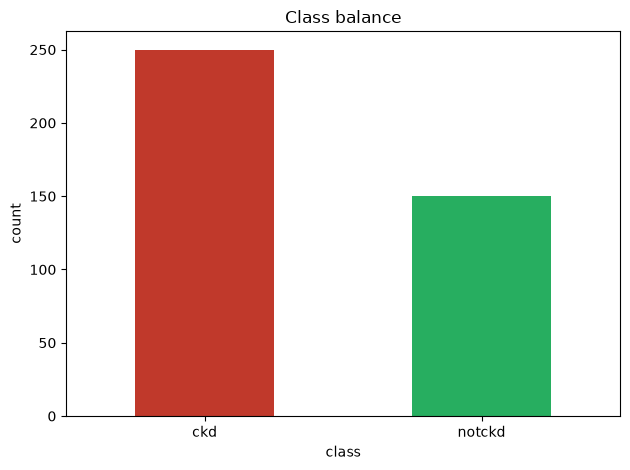

In [ ]:
from src.data.preprocess import clean_target
target_clean = clean_target(df[config.TARGET_COLUMN])
counts = target_clean.value_counts()
print(counts)
counts.plot(kind="bar", title="Class balance", color=["#c0392b", "#27ae60"])
plt.ylabel("count")
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig("class_balance.png", dpi=100)
plt.show()

**Finding:** 250 CKD-positive vs 150 CKD-negative — moderately imbalanced (62.5% / 37.5%), not severe enough to require resampling (e.g. SMOTE), but worth using stratified splitting (already done in `split_train_test`) and prioritizing recall over raw accuracy when evaluating in Sprint 2, exactly as planned in the PRD's success metrics.

## Numeric feature distributions

In [ ]:
df[config.NUMERIC_COLUMNS].apply(pd.to_numeric, errors="coerce").describe().T

,count,mean,std,min,25%,50%,75%,max
age,391.0,51.483376,17.169714,2.000,42.00,55.00,64.50,90.000
bp,388.0,76.469072,13.683637,50.000,70.00,80.00,80.00,180.000
sg,353.0,1.017408,0.005717,1.005,1.01,1.02,1.02,1.025
al,354.0,1.016949,1.352679,0.000,0.00,0.00,2.00,5.000
su,351.0,0.450142,1.099191,0.000,0.00,0.00,0.00,5.000
bgr,356.0,148.036517,79.281714,22.000,99.00,121.00,163.00,490.000
bu,381.0,57.425722,50.503006,1.500,27.00,42.00,66.00,391.000
sc,383.0,3.072454,5.741126,0.400,0.90,1.30,2.80,76.000
sod,313.0,137.528754,10.408752,4.500,135.00,138.00,142.00,163.000
pot,312.0,4.627244,3.193904,2.500,3.80,4.40,4.90,47.000


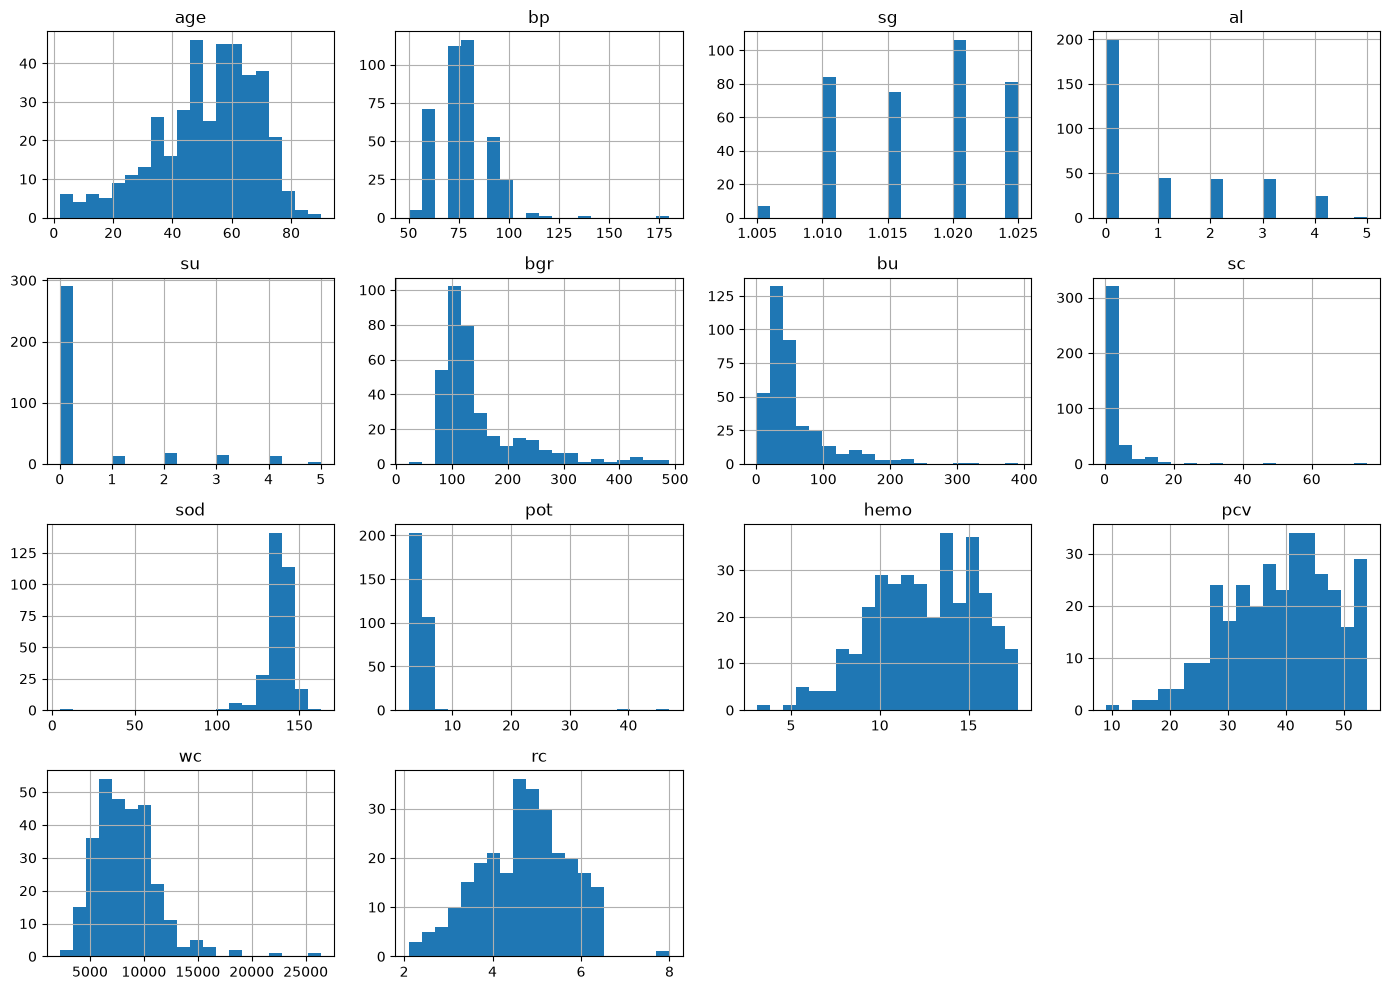

In [ ]:
numeric_df = df[config.NUMERIC_COLUMNS].apply(pd.to_numeric, errors="coerce")
numeric_df.hist(figsize=(14, 10), bins=20)
plt.tight_layout()
plt.savefig("feature_distributions.png", dpi=100)
plt.show()

**Finding:** several lab values (`wc`, `sc`, `bu`) are heavily right-skewed with a handful of extreme outliers — plausible for real lab data (a very sick patient can have values many times the normal range), so these are left as genuine values rather than removed, but it's worth remembering tree-based models (Random Forest, XGBoost) handle this kind of skew far more gracefully than distance-based models (SVM, k-NN) when comparing candidates in Sprint 2.

## Binary/categorical feature value counts

In [ ]:
for col in config.BINARY_COLUMNS:
    print(col, "->", dict(df[col].value_counts(dropna=False)))

rbc -> {'normal': np.int64(201), nan: np.int64(152), 'abnormal': np.int64(47)}
pc -> {'normal': np.int64(259), 'abnormal': np.int64(76), nan: np.int64(65)}
pcc -> {'notpresent': np.int64(354), 'present': np.int64(42), nan: np.int64(4)}
ba -> {'notpresent': np.int64(374), 'present': np.int64(22), nan: np.int64(4)}
htn -> {'no': np.int64(251), 'yes': np.int64(147), nan: np.int64(2)}
dm -> {'no': np.int64(258), 'yes': np.int64(134), '\tno': np.int64(3), '\tyes': np.int64(2), nan: np.int64(2), ' yes': np.int64(1)}
cad -> {'no': np.int64(362), 'yes': np.int64(34), '\tno': np.int64(2), nan: np.int64(2)}
appet -> {'good': np.int64(317), 'poor': np.int64(82), nan: np.int64(1)}
pe -> {'no': np.int64(323), 'yes': np.int64(76), nan: np.int64(1)}
ane -> {'no': np.int64(339), 'yes': np.int64(60), nan: np.int64(1)}


**Finding (data quality):** raw values in this column set were messier than expected on first inspection — the target column had a couple of tab-contaminated `"ckd\t"` entries, several numeric columns (`pcv`, `wc`, `rc`) contained stray `"\t?"`/`"\t43"`-style tokens instead of clean numbers, and the `appet` column uses a `good`/`poor` pair that isn't covered by the more common `yes/no`, `normal/abnormal`, `present/notpresent` pairs. All of this is now handled explicitly in `src/data/preprocess.py` (`clean_target`, the numeric coercion in `load_raw_tabular`, and the expanded mapping in `encode_binary_column`), each with a regression test in `tests/test_preprocess.py` so these don't silently reappear.

## Summary of decisions this EDA informs

- Missing values: impute (median for numeric, most-frequent for binary) rather than drop rows — dropping would lose ~38% of rows given `rbc`'s missingness alone.
- Class imbalance (62.5/37.5): stratified train/test split, prioritize recall in Sprint 2 evaluation.
- Skewed numeric features: favor tree-based models (Random Forest, XGBoost) as strong candidates in Sprint 2.
- Raw data quality issues (dirty strings, missing `good`/`poor` mapping): fixed in code, covered by tests, documented here and in code comments rather than silently patched.